In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dongrelaxman/amazon-reviews-dataset/Amazon_Reviews.csv


In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
import os
import numpy as np
from gensim.models import Word2Vec


def build_word2vec(X_train,
                   vector_size=100,
                   window=5,
                   min_count=2,
                   workers=4,
                   sg=1,
                   epochs=10,
                   seed=42):
    """
    Train a Word2Vec model on the training corpus ONLY.

    بيتدرب على X_train بس عشان منعملش data leakage.

    Args:
        X_train     : iterable of cleaned text strings (training set).
        vector_size : number of dimensions per word vector.
        window      : context window size (words before and after).
        min_count   : ignore words appearing fewer than this many times.
        workers     : number of parallel threads.
        sg          : 1 = Skip-gram | 0 = CBOW.
        epochs      : number of training passes over the corpus.
        seed        : random seed for reproducibility.

    Returns:
        Trained gensim Word2Vec model.
    """
    train_tokens = [text.split() for text in X_train]

    model = Word2Vec(
        sentences=train_tokens,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=sg,
        epochs=epochs,
        seed=seed,
    )

    print(f"[Word2Vec] Vocabulary size     : {len(model.wv):,} words")
    print(f"[Word2Vec] Embedding dimensions: {model.vector_size}")

    return model


def review_to_vec(tokens, model, vector_size=100):
    """
    Convert a list of word tokens to a single averaged vector.

    الكلمات اللي مش موجودة في الـ vocabulary بيتم تجاهلها.
    لو المراجعة كلها كلمات غير موجودة بيرجع zero vector.

    Args:
        tokens      : list of word strings.
        model       : trained Word2Vec model.
        vector_size : fallback vector size for OOV reviews.

    Returns:
        numpy array of shape (vector_size,).
    """
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


def transform_word2vec(X, model):
    """
    Transform a text split into averaged Word2Vec embedding matrix.

    بتحوّل كل مراجعة لـ vector واحد بعمل متوسط لكل كلماتها.

    Args:
        X     : iterable of cleaned text strings.
        model : trained Word2Vec model.

    Returns:
        numpy array of shape (n_samples, vector_size).
    """
    size = model.vector_size
    embeddings = np.array([review_to_vec(text.split(), model, size) for text in X])
    print(f"[Word2Vec] Embedding matrix: {embeddings.shape}")
    return embeddings


def save_word2vec(model, X_train_w2v, X_test_w2v,
                  out_dir="outputs/features"):
    """
    Save Word2Vec model and embedding arrays to disk.

    Args:
        model       : trained Word2Vec model.
        X_train_w2v : numpy array of training embeddings.
        X_test_w2v  : numpy array of test embeddings.
        out_dir     : directory to save files.
    """
    os.makedirs(out_dir, exist_ok=True)

    model.save(os.path.join(out_dir, "word2vec.model"))
    np.save(os.path.join(out_dir, "X_train_w2v.npy"), X_train_w2v)
    np.save(os.path.join(out_dir, "X_test_w2v.npy"),  X_test_w2v)

    print(f"[Word2Vec] Model and embeddings saved to: {out_dir}")


def load_word2vec(out_dir="outputs/features"):
    """
    Load a previously saved Word2Vec model and embedding arrays.

    Returns:
        model       : trained Word2Vec model.
        X_train_w2v : numpy array of training embeddings.
        X_test_w2v  : numpy array of test embeddings.
    """
    model       = Word2Vec.load(os.path.join(out_dir, "word2vec.model"))
    X_train_w2v = np.load(os.path.join(out_dir, "X_train_w2v.npy"))
    X_test_w2v  = np.load(os.path.join(out_dir, "X_test_w2v.npy"))

    print(f"[Word2Vec] Loaded from: {out_dir}")
    return model, X_train_w2v, X_test_w2v


def get_similar_words(model, word, topn=5):
    """
    Return the most similar words to a given word.
    مفيدة لاختبار إن الـ model اتعلم صح.

    Args:
        model : trained Word2Vec model.
        word  : query word string.
        topn  : number of similar words to return.

    Returns:
        List of (word, similarity_score) tuples,
        or empty list if word not in vocabulary.
    """
    if word in model.wv:
        return model.wv.most_similar(word, topn=topn)
    else:
        print(f"[Word2Vec] '{word}' not in vocabulary.")
        return []


In [5]:
import os
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords


CUSTOM_STOP = ['text', 'found', 'review', 'amazon', 'review text', 'text found']

def build_tfidf(X_train,
                max_features=10000,
                ngram_range=(1, 2),
                sublinear_tf=True,
                min_df=3,
                max_df=0.90):
    
    # جمعي الـ stopwords
    all_stops = list(stopwords.words("english")) + CUSTOM_STOP

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        sublinear_tf=sublinear_tf,
        min_df=min_df,
        max_df=max_df,
        stop_words=all_stops 
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)

    print(f"[TF-IDF] Vocabulary size : {len(vectorizer.vocabulary_):,} terms")
    print(f"[TF-IDF] Train matrix    : {X_train_tfidf.shape}")

    return vectorizer, X_train_tfidf


def transform_tfidf(vectorizer, X):
    """
    Transform a text split using an already-fitted TF-IDF vectorizer.

    Args:
        vectorizer : fitted TfidfVectorizer (from build_tfidf).
        X          : iterable of cleaned text strings (val or test set).

    Returns:
        Sparse matrix of TF-IDF features.
    """
    X_tfidf = vectorizer.transform(X)
    print(f"[TF-IDF] Transformed matrix: {X_tfidf.shape}")
    return X_tfidf


def save_vectorizer(vectorizer, path="outputs/features/tfidf_vectorizer.pkl"):
    """
    Save the fitted TF-IDF vectorizer to disk.
    بنحفظه عشان نقدر نستخدمه تاني من غير ما نعيد التدريب.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(vectorizer, f)
    print(f"[TF-IDF] Vectorizer saved to: {path}")


def load_vectorizer(path="outputs/features/tfidf_vectorizer.pkl"):
    """Load a previously saved TF-IDF vectorizer from disk."""
    with open(path, "rb") as f:
        vectorizer = pickle.load(f)
    print(f"[TF-IDF] Vectorizer loaded from: {path}")
    return vectorizer


def get_top_terms(vectorizer, X_tfidf, y, sentiment_value, top_n=15):
    """
    Return the top TF-IDF terms for a given sentiment class.
    مفيدة في الـ insights عشان توضح أهم الكلمات لكل sentiment.

    Args:
        vectorizer      : fitted TfidfVectorizer.
        X_tfidf         : sparse matrix (training split).
        y               : array-like of labels (0 or 1).
        sentiment_value : 0 = Negative | 1 = Positive.
        top_n           : number of top terms to return.

    Returns:
        terms  : list of term strings.
        scores : list of mean TF-IDF scores.
    """
    feature_names = vectorizer.get_feature_names_out()
    y = np.array(y)
    mask = (y == sentiment_value)
    mean_scores = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:top_n]
    return feature_names[top_idx].tolist(), mean_scores[top_idx].tolist()


In [9]:
data = pd.read_csv(
    "/kaggle/input/datasets/dongrelaxman/amazon-reviews-dataset/Amazon_Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

In [14]:
# 2️⃣ Drop missing critical columns
data = data.dropna(subset=['Review Text', 'Rating'])

# 3️⃣ Convert Rating to int (handling weird formats safely)
data['Rating'] = data['Rating'].astype(str).str.extract(r'(\d+)')
data = data.dropna(subset=['Rating'])
data['Rating'] = data['Rating'].astype(int)

# 4️⃣ Create Sentiment from Rating
# 5-4 → Positive (1)
# 1-2 → Negative (0)
# 3   → removed (neutral)
data['Sentiment'] = data['Rating'].apply(
    lambda x: 1 if x >= 4 else (0 if x <= 2 else None)
)

# 5️⃣ Remove neutral reviews (Rating = 3)
data = data.dropna(subset=['Sentiment'])
data['Sentiment'] = data['Sentiment'].astype(int)

# 6️⃣ Define features & labels
X = data['Review Text'].astype(str)
y = data['Sentiment']

# 7️⃣ Quick sanity check
print("Final dataset shape:", data.shape)
print(data['Sentiment'].value_counts())
data.head()

Final dataset shape: (20170, 10)
Sentiment
0    14350
1     5820
Name: count, dtype: int64


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Sentiment
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,1,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024",0
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,1,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024",0
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,1,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024",0
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,1,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024",0
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,1,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024",0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Build TF-IDF**

In [16]:
tfidf_vectorizer, X_train_tfidf = build_tfidf(X_train)
X_test_tfidf = transform_tfidf(tfidf_vectorizer, X_test)

[TF-IDF] Vocabulary size : 10,000 terms
[TF-IDF] Train matrix    : (16136, 10000)
[TF-IDF] Transformed matrix: (4034, 10000)


**Logistic Regression Training**

In [17]:
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print("=== TF-IDF + Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))
print(confusion_matrix(y_test, y_pred_tfidf))

=== TF-IDF + Logistic Regression ===
Accuracy: 0.93728309370352
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2870
           1       0.91      0.87      0.89      1164

    accuracy                           0.94      4034
   macro avg       0.93      0.92      0.92      4034
weighted avg       0.94      0.94      0.94      4034

[[2766  104]
 [ 149 1015]]


**Word2Vec + Logistic Regression**

In [19]:
w2v_model = build_word2vec(X_train)
X_train_w2v = transform_word2vec(X_train, w2v_model)
X_test_w2v = transform_word2vec(X_test, w2v_model)

[Word2Vec] Vocabulary size     : 24,309 words
[Word2Vec] Embedding dimensions: 100
[Word2Vec] Embedding matrix: (16136, 100)
[Word2Vec] Embedding matrix: (4034, 100)


**Logistic Regression Training**

In [20]:
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred_w2v = lr_w2v.predict(X_test_w2v)

print("=== Word2Vec + Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v))
print(confusion_matrix(y_test, y_pred_w2v))

=== Word2Vec + Logistic Regression ===
Accuracy: 0.9134853743182945
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2870
           1       0.89      0.80      0.84      1164

    accuracy                           0.91      4034
   macro avg       0.91      0.88      0.89      4034
weighted avg       0.91      0.91      0.91      4034

[[2754  116]
 [ 233  931]]


**Comparison**

In [22]:
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("Word2Vec Accuracy:", accuracy_score(y_test, y_pred_w2v))

TF-IDF Accuracy: 0.93728309370352
Word2Vec Accuracy: 0.9134853743182945


**Visualizations**

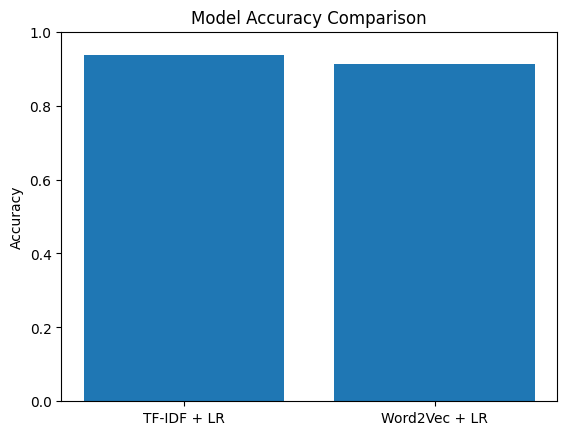

In [25]:
import matplotlib.pyplot as plt

models = ['TF-IDF + LR', 'Word2Vec + LR']
accuracies = [accuracy_score(y_test, y_pred_tfidf),
              accuracy_score(y_test, y_pred_w2v)]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

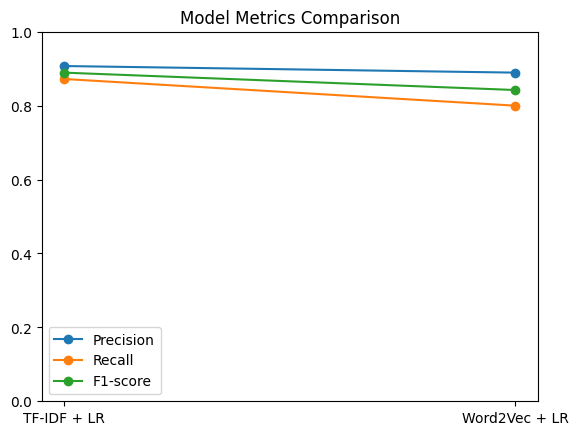

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "Precision": [
        precision_score(y_test, y_pred_tfidf),
        precision_score(y_test, y_pred_w2v)
    ],
    "Recall": [
        recall_score(y_test, y_pred_tfidf),
        recall_score(y_test, y_pred_w2v)
    ],
    "F1": [
        f1_score(y_test, y_pred_tfidf),
        f1_score(y_test, y_pred_w2v)
    ]
}

x = range(len(models))

plt.plot(x, metrics["Precision"], marker='o', label="Precision")
plt.plot(x, metrics["Recall"], marker='o', label="Recall")
plt.plot(x, metrics["F1"], marker='o', label="F1-score")

plt.xticks(x, models)
plt.title("Model Metrics Comparison")
plt.legend()
plt.ylim(0, 1)
plt.show()

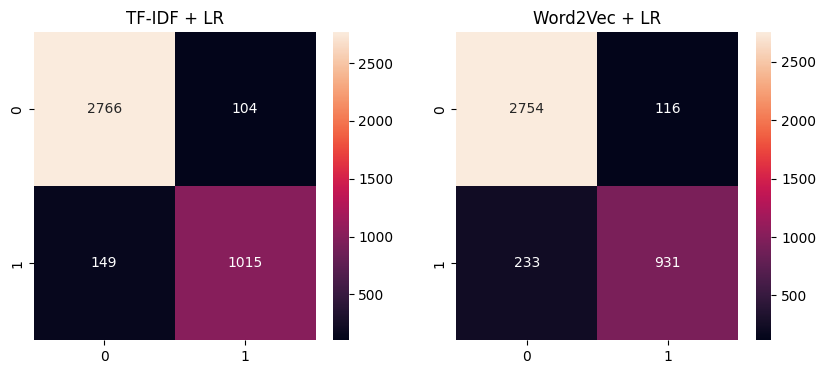

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm1 = confusion_matrix(y_test, y_pred_tfidf)
cm2 = confusion_matrix(y_test, y_pred_w2v)

sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("TF-IDF + LR")

sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Word2Vec + LR")

plt.show()

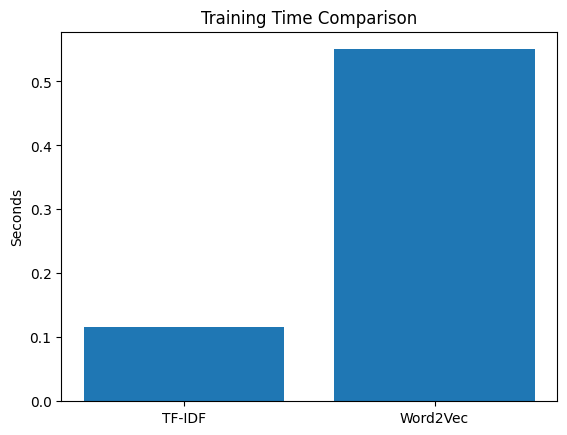

In [28]:
import time

start = time.time()
lr_tfidf.fit(X_train_tfidf, y_train)
tfidf_time = time.time() - start

start = time.time()
lr_w2v.fit(X_train_w2v, y_train)
w2v_time = time.time() - start

plt.bar(['TF-IDF', 'Word2Vec'], [tfidf_time, w2v_time])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

**Save models + Vectorizers**

In [29]:
import pickle
import os

os.makedirs("/kaggle/working/saved_models", exist_ok=True)

# Logistic Regression (TF-IDF)
with open("/kaggle/working/saved_models/lr_tfidf.pkl", "wb") as f:
    pickle.dump(lr_tfidf, f)

# TF-IDF Vectorizer
with open("/kaggle/working/saved_models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)


# Word2Vec model
w2v_model.save("/kaggle/working/saved_models/word2vec.model")

# Logistic Regression trained on Word2Vec features
with open("/kaggle/working/saved_models/lr_w2v.pkl", "wb") as f:
    pickle.dump(lr_w2v, f)